# Clustering with a Wine Dataset

## Project Overview

This project is about unsupervised machine learning using clustering methods. We have a wine dataset, which contains chemical measurements of different wines. The true wine classes are available in the dataset, but they are not used to train the clustering models. They are used only later to help evaluate how well the clusters match the known wine groups.

## Methods Used

- K Means Clustering
- Hierarchical Clustering
- DBSCAN
- Feature scaling
- Elbow method
- Silhouette score
- PCA visualization
- Cluster interpretation

## Main Goal

The goal is to identify natural groups in the data and evaluate whether the clustering algorithms can recover meaningful wine groupings based only on the feature values.

### Import libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score
)

### Load the dataset

In [3]:
wine = load_wine(as_frame=True)

df = wine.frame.copy()

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  target          

### Remove the target variable before training

The target labels are not used for clustering. They are kept only for external evaluation after the clustering models are fitted.

In [5]:
df["target"].value_counts()

target
1    71
0    59
2    48
Name: count, dtype: int64

### Define features and true labels

In [6]:
X = df.drop(columns="target")

true_labels = df["target"]

### Scale the features

Clustering is distance based, so scaling is very important. Features with large values can dominate the distance calculation.

In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


### K-Means clustering

K Means groups observations into a fixed number of clusters. It tries to minimize the distance between each observation and the center of its assigned cluster.

Since the Wine dataset has three known wine classes, we start with three clusters.

In [8]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

df["kmeans_cluster"] = kmeans_labels

df[["target", "kmeans_cluster"]].head()

,target,kmeans_cluster
0,0,2
1,0,2
2,0,2
3,0,2
4,0,2


#### Evaluate K Means

The silhouette score measures how well separated the clusters are. Higher values are better.

The Davies Bouldin score measures cluster overlap. Lower values are better.

The Calinski Harabasz score measures how dense and well separated the clusters are. Higher values are better.

The Adjusted Rand Index compares the clusters to the true wine labels. It is used only for evaluation because the true labels are not used during clustering.

In [9]:
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_db = davies_bouldin_score(X_scaled, kmeans_labels)
kmeans_ch = calinski_harabasz_score(X_scaled, kmeans_labels)
kmeans_ari = adjusted_rand_score(true_labels, kmeans_labels)

print("K Means Clustering Performance")
print("------------------------------")
print(f"Silhouette Score:       {kmeans_silhouette:.3f}")
print(f"Davies Bouldin Score:   {kmeans_db:.3f}")
print(f"Calinski Harabasz Score:{kmeans_ch:.3f}")
print(f"Adjusted Rand Index:    {kmeans_ari:.3f}")

K Means Clustering Performance
------------------------------
Silhouette Score:       0.285
Davies Bouldin Score:   1.389
Calinski Harabasz Score:70.940
Adjusted Rand Index:    0.897


K-Means performs well on this dataset. The high Adjusted Rand Index of 0.897 shows that the predicted clusters closely match the true wine classes. However, the silhouette score of 0.285 suggests that the clusters are only moderately separated, meaning some observations may overlap across groups. Overall, K-Means identifies meaningful structure, but the clusters are not perfectly distinct.

#### Elbow method for choosing K

The elbow method looks for the point where adding more clusters gives only a small improvement. This point is called the elbow. It suggests a reasonable number of clusters.

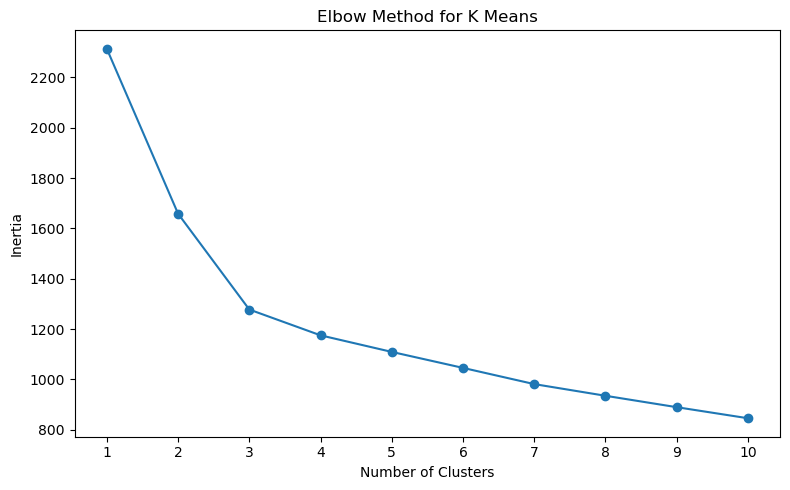

In [10]:
inertia_values = []

k_values = range(1, 11)

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    model.fit(X_scaled)
    inertia_values.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia_values, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for K Means")
plt.xticks(k_values)
plt.tight_layout()
plt.show()

### Silhouette scores for different K values

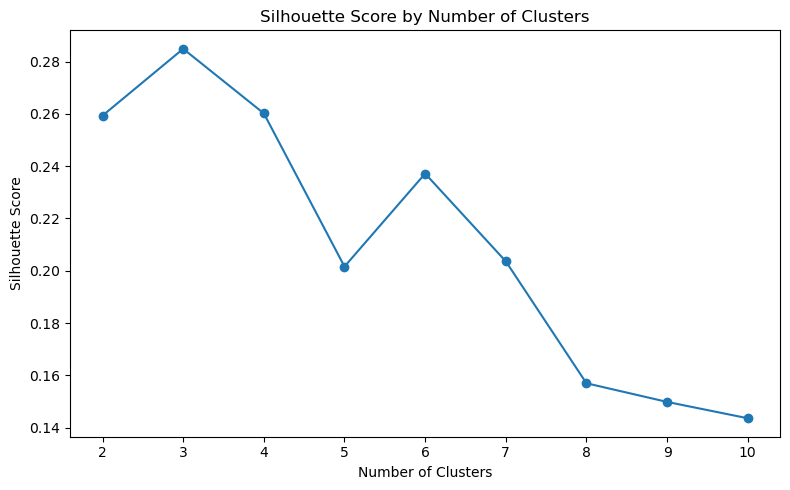

In [11]:
silhouette_scores = []

k_values = range(2, 11)

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.xticks(k_values)
plt.tight_layout()
plt.show()

### Hierarchical clustering

Hierarchical clustering builds clusters step by step by merging similar observations or groups.

In [12]:
hierarchical = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

hierarchical_labels = hierarchical.fit_predict(X_scaled)

df["hierarchical_cluster"] = hierarchical_labels

In [13]:
hierarchical_silhouette = silhouette_score(X_scaled, hierarchical_labels)
hierarchical_db = davies_bouldin_score(X_scaled, hierarchical_labels)
hierarchical_ch = calinski_harabasz_score(X_scaled, hierarchical_labels)
hierarchical_ari = adjusted_rand_score(true_labels, hierarchical_labels)

print("Hierarchical Clustering Performance")
print("-----------------------------------")
print(f"Silhouette Score:       {hierarchical_silhouette:.3f}")
print(f"Davies Bouldin Score:   {hierarchical_db:.3f}")
print(f"Calinski Harabasz Score:{hierarchical_ch:.3f}")
print(f"Adjusted Rand Index:    {hierarchical_ari:.3f}")

Hierarchical Clustering Performance
-----------------------------------
Silhouette Score:       0.277
Davies Bouldin Score:   1.419
Calinski Harabasz Score:67.647
Adjusted Rand Index:    0.790


Hierarchical clustering performs fairly well, with an Adjusted Rand Index of 0.790, meaning its clusters are reasonably close to the true wine classes. However, the modest silhouette score shows that the clusters are not strongly separated. Compared with K Means, hierarchical clustering is slightly weaker on this dataset.

### DBSCAN clustering

DBSCAN groups points that are close together and marks isolated points as noise.

Unlike K-Means, DBSCAN does not require us to choose the number of clusters in advance.

In [14]:
dbscan = DBSCAN(
    eps=2.2,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

df["dbscan_cluster"] = dbscan_labels

In [15]:
# Check cluster counts
pd.Series(dbscan_labels).value_counts().sort_index()

-1    55
 0    86
 1    37
Name: count, dtype: int64

In DBSCAN, -1 means noise

Evaluate DBSCAN only if it finds more than one cluster:

In [17]:
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

if n_clusters_dbscan > 1:
    dbscan_silhouette = silhouette_score(X_scaled, dbscan_labels)
    dbscan_db = davies_bouldin_score(X_scaled, dbscan_labels)
    dbscan_ch = calinski_harabasz_score(X_scaled, dbscan_labels)
    dbscan_ari = adjusted_rand_score(true_labels, dbscan_labels)

    print("DBSCAN Clustering Performance")
    print("-----------------------------")
    print(f"Number of clusters:      {n_clusters_dbscan}")
    print(f"Silhouette Score:        {dbscan_silhouette:.3f}")
    print(f"Davies Bouldin Score:    {dbscan_db:.3f}")
    print(f"Calinski Harabasz Score: {dbscan_ch:.3f}")
    print(f"Adjusted Rand Index:     {dbscan_ari:.3f}")
else:
    print("DBSCAN did not find enough clusters for evaluation.")

DBSCAN Clustering Performance
-----------------------------
Number of clusters:      2
Silhouette Score:        0.143
Davies Bouldin Score:    3.386
Calinski Harabasz Score: 25.829
Adjusted Rand Index:     0.329


### Compare clustering models

In [18]:
comparison_results = []

comparison_results.append({
    "Model": "K-Means",
    "Silhouette Score": kmeans_silhouette,
    "Davies Bouldin Score": kmeans_db,
    "Calinski Harabasz Score": kmeans_ch,
    "Adjusted Rand Index": kmeans_ari
})

comparison_results.append({
    "Model": "Hierarchical Clustering",
    "Silhouette Score": hierarchical_silhouette,
    "Davies Bouldin Score": hierarchical_db,
    "Calinski Harabasz Score": hierarchical_ch,
    "Adjusted Rand Index": hierarchical_ari
})

if n_clusters_dbscan > 1:
    comparison_results.append({
        "Model": "DBSCAN",
        "Silhouette Score": dbscan_silhouette,
        "Davies Bouldin Score": dbscan_db,
        "Calinski Harabasz Score": dbscan_ch,
        "Adjusted Rand Index": dbscan_ari
    })

comparison_df = pd.DataFrame(comparison_results)

comparison_df.sort_values(
    by="Silhouette Score",
    ascending=False
)

,Model,Silhouette Score,Davies Bouldin Score,Calinski Harabasz Score,Adjusted Rand Index
0,K-Means,0.284859,1.389188,70.940008,0.897495
1,Hierarchical Clustering,0.277444,1.418592,67.647468,0.789933
2,DBSCAN,0.142678,3.386438,25.829112,0.329126


### PCA for visualization

The dataset has many features, so we use PCA to reduce it to two dimensions for plotting.

In [19]:
pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["true_label"] = true_labels
pca_df["kmeans_cluster"] = kmeans_labels
pca_df["hierarchical_cluster"] = hierarchical_labels
pca_df["dbscan_cluster"] = dbscan_labels

pca_df.head()

,PC1,PC2,true_label,kmeans_cluster,hierarchical_cluster,dbscan_cluster
0,3.316751,1.443463,0,2,2,0
1,2.209465,-0.333393,0,2,2,0
2,2.516740,1.031151,0,2,2,0
3,3.757066,2.756372,0,2,2,0
4,1.008908,0.869831,0,2,2,0


## Clustering Model Comparison

K-Means is the best-performing clustering model in this analysis. It has the highest silhouette score, the lowest Davies-Bouldin score, the highest Calinski-Harabasz score, and the highest Adjusted Rand Index. The high ARI of 0.897 shows that K-Means recovered the true wine groups very well, even though the target labels were not used during training.

Hierarchical clustering also performs reasonably well, but it is slightly weaker than K-Means across all metrics. Its ARI of 0.790 still suggests meaningful clustering, but the groups are less aligned with the true wine classes.

DBSCAN performs the weakest in this comparison. Its low silhouette score, high Davies-Bouldin score, low Calinski-Harabasz score, and low ARI suggest that it did not identify the wine groups as effectively. This may be because DBSCAN is sensitive to the choice of `eps` and `min_samples`, and the wine data may not have the type of density-based cluster structure DBSCAN works best with.

Overall, K-Means is the preferred model for this dataset.

In [20]:
# Explained variance

explained_variance = pca.explained_variance_ratio_

print(f"PC1 explained variance: {explained_variance[0]:.3f}")
print(f"PC2 explained variance: {explained_variance[1]:.3f}")
print(f"Total explained variance: {explained_variance.sum():.3f}")

PC1 explained variance: 0.362
PC2 explained variance: 0.192
Total explained variance: 0.554


The first two principal components explain 55.4 percent of the total variation in the data. This means the PCA plot captures a meaningful share of the dataset’s structure, making it useful for visualizing clusters. However, because 44.6 percent of the variation is not shown, the two dimensional plot should be interpreted as a simplified view rather than a complete representation of the data.

### Plot K-Means clusters

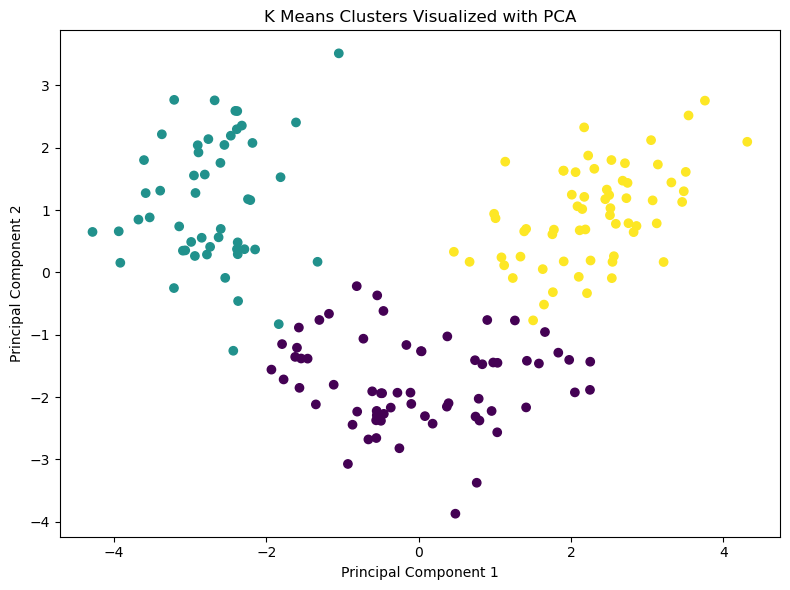

In [21]:
plt.figure(figsize=(8, 6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["kmeans_cluster"]
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K Means Clusters Visualized with PCA")
plt.tight_layout()
plt.show()

### Plot hierarchical clusters

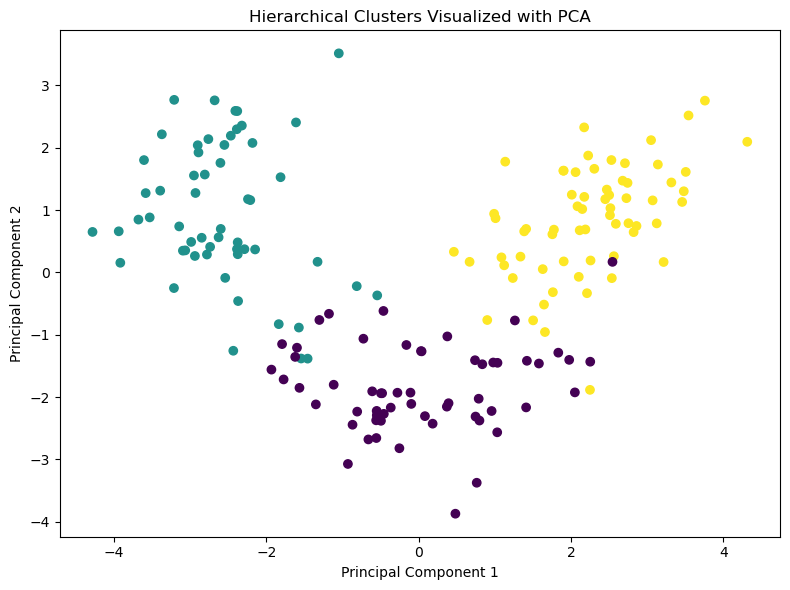

In [22]:
plt.figure(figsize=(8, 6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["hierarchical_cluster"]
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Hierarchical Clusters Visualized with PCA")
plt.tight_layout()
plt.show()

### Plot DBSCAN clusters

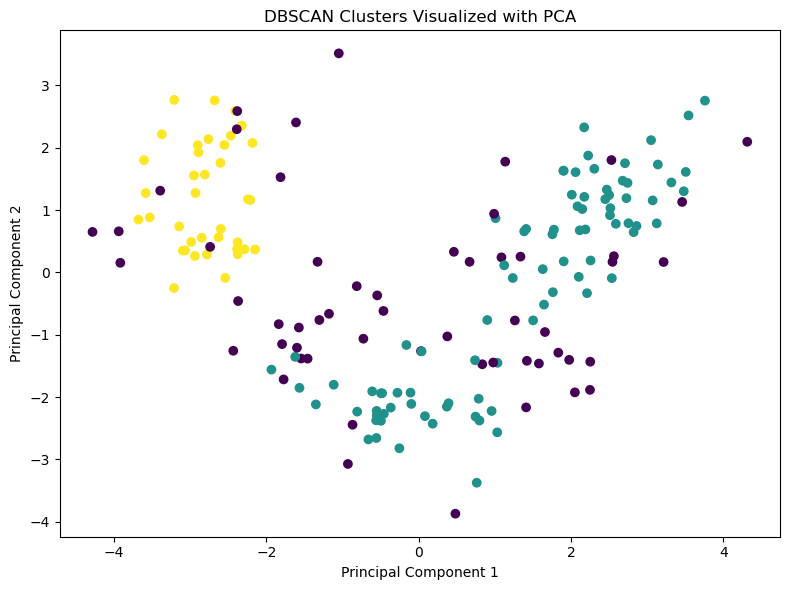

In [23]:
plt.figure(figsize=(8, 6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["dbscan_cluster"]
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DBSCAN Clusters Visualized with PCA")
plt.tight_layout()
plt.show()

### Plot true labels for comparison

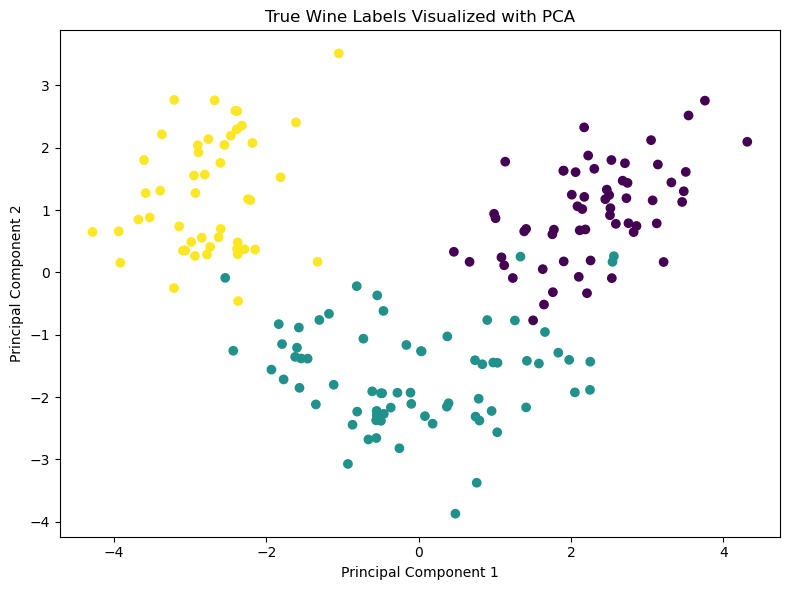

In [24]:
plt.figure(figsize=(8, 6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["true_label"]
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("True Wine Labels Visualized with PCA")
plt.tight_layout()
plt.show()

NB: The true labels are not used during clustering. This plot is included only to compare whether the unsupervised clusters resemble the known wine classes.

### Cluster profiling

Cluster profiling helps us understand what makes each cluster different.

In [25]:
profile_df = X.copy()
profile_df["kmeans_cluster"] = kmeans_labels

cluster_profile = profile_df.groupby("kmeans_cluster").mean()

cluster_profile

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
kmeans_cluster,,,,,,,,,,,,,
0,12.250923,1.897385,2.231231,20.063077,92.738462,2.247692,2.050000,0.357692,1.624154,2.973077,1.062708,2.803385,510.169231
1,13.134118,3.307255,2.417647,21.241176,98.666667,1.683922,0.818824,0.451961,1.145882,7.234706,0.691961,1.696667,619.058824
2,13.676774,1.997903,2.466290,17.462903,107.967742,2.847581,3.003226,0.292097,1.922097,5.453548,1.065484,3.163387,1100.225806


In [26]:
# Transpose
cluster_profile.T

kmeans_cluster,0,1,2
alcohol,12.250923,13.134118,13.676774
malic_acid,1.897385,3.307255,1.997903
ash,2.231231,2.417647,2.466290
alcalinity_of_ash,20.063077,21.241176,17.462903
magnesium,92.738462,98.666667,107.967742
total_phenols,2.247692,1.683922,2.847581
flavanoids,2.050000,0.818824,3.003226
nonflavanoid_phenols,0.357692,0.451961,0.292097
proanthocyanins,1.624154,1.145882,1.922097
color_intensity,2.973077,7.234706,5.453548


### Inspecting the most different features by cluster

In [27]:
cluster_profile_range = cluster_profile.max() - cluster_profile.min()

cluster_profile_range.sort_values(ascending=False).head(10)

proline                         590.056576
magnesium                        15.229280
color_intensity                   4.261629
alcalinity_of_ash                 3.778273
flavanoids                        2.184402
od280/od315_of_diluted_wines      1.466720
alcohol                           1.425851
malic_acid                        1.409870
total_phenols                     1.163659
proanthocyanins                   0.776214
dtype: float64

### Make a prediction for a new observation with K-Means

In [28]:
new_observation = X.iloc[[0]]

new_observation_scaled = scaler.transform(new_observation)

new_cluster = kmeans.predict(new_observation_scaled)

print("New Observation Cluster")
print("-----------------------")
print(f"Assigned cluster: {new_cluster[0]}")

New Observation Cluster
-----------------------
Assigned cluster: 2


In [29]:
new_observation

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.8,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
